HEART DISEASE DATASET
Shape: (303, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Target distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
th

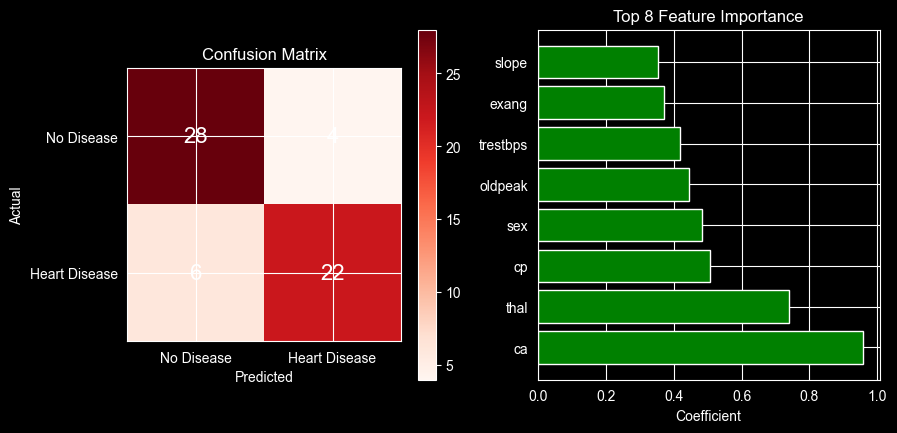

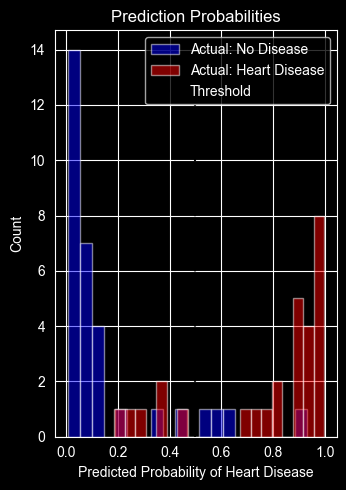

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix, f1_score
import matplotlib.pyplot as plt


# Load Heart Disease dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=column_names, na_values='?')

print("=" * 60)
print("HEART DISEASE DATASET")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nTarget distribution:")
print(df['target'].value_counts())

# Handle missing values
print(f"\nMissing values before cleaning:")
print(df.isnull().sum())

# Drop rows with missing values (few in this dataset)
df = df.dropna()
print(df.isnull().sum())
# Convert target to binary (0 = no disease, 1 = disease)
# Original has 0-4, where 0 = no disease, 1-4 = disease
df['target'] = (df['target'] > 0).astype(int)

print(f"\nAfter cleaning - Shape: {df.shape}")
print(f"Binary target distribution:")
print(df['target'].value_counts())

# Separate features and target
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X = df[feature_cols].values
y = df['target'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Features: {feature_cols}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for i in range(self.n_iterations):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            cost = -1/n_samples * np.sum(y.reshape(-1,1) * np.log(y_pred + 1e-15) +
                                         (1 - y.reshape(-1,1)) * np.log(1 - y_pred + 1e-15))
            self.cost_history.append(cost)

            error = y_pred - y.reshape(-1,1)
            dw = (1/n_samples) * np.dot(X.T, error)
            db = (1/n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "=" * 60)
print("HEART DISEASE PREDICTION RESULTS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"\nConfusion Matrix:")
print(f"              Predicted")
print(f"              No Disease  Heart Disease")
print(f"Actual No Disease     {cm[0,0]:3d}       {cm[0,1]:3d}")
print(f"Actual Heart Disease {cm[1,0]:3d}       {cm[1,1]:3d}")

# Print actual coefficients
print("\n" + "=" * 60)
print(" MODEL'S COEFFICIENTS")
print("=" * 60)

for feature, coef in zip(feature_cols, model.coef_[0]):
    print(f"{feature:12s}: {coef:8.4f}")

# Find top 3
coef_list = list(zip(feature_cols, model.coef_[0]))
coef_list.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n✅ TOP 3 FEATURES:")
for i in range(3):
    print(f"   {i+1}. {coef_list[i][0]}: {coef_list[i][1]:.4f}")

# ============================================
#  PLOTTING
# ============================================
import os
os.makedirs('week3_logistic_regression', exist_ok=True)

plt.figure(figsize=(15, 10))

# Plot 1: Confusion Matrix
# plot_confusion_matrix(y_test, y_pred, class_names=['No Disease', 'Heart Disease'])
plt.subplot(2, 3, 1)
plt.imshow(cm, interpolation='nearest', cmap='Reds')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.yticks([0, 1], ['No Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16)

# Plot 2: Feature Importance
# plot_feature_importance(feature_cols, model.coef_[0])
plt.subplot(2, 3, 2)
coefficients = model.coef_[0] if hasattr(model, 'coef_') else model.weights.flatten()
sorted_idx = np.argsort(np.abs(coefficients))[::-1]
sorted_names = [feature_cols[i] for i in sorted_idx[:8]]  # Top 8 features
sorted_coefs = coefficients[sorted_idx[:8]]
colors = ['red' if c < 0 else 'green' for c in sorted_coefs]
plt.barh(sorted_names, sorted_coefs, color=colors)
plt.xlabel('Coefficient')
plt.title('Top 8 Feature Importance')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# # Plot 3: Probability Distribution
# plot_probability_distribution(y_test, y_proba, class_names=['No Disease', 'Heart Disease'])
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 3)
plt.hist(y_proba[y_test == 0], bins=20, alpha=0.5, label='Actual: No Disease', color='blue')
plt.hist(y_proba[y_test == 1], bins=20, alpha=0.5, label='Actual: Heart Disease', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
plt.xlabel(f'Predicted Probability of {['No Disease', 'Heart Disease'][1]}')
plt.ylabel('Count')
plt.title('Prediction Probabilities')
plt.legend()

plt.tight_layout()
plt.savefig('week3_logistic_regression/breast_cancer_results.png')
plt.show()